# Steinmetz post-clustering waveform audit

This notebook audits **only units already retained and assigned by the existing clustering**.

> Run this notebook after Notebook 03 and before Notebook 09. It writes unit-level audit annotations only. It does not rerun clustering or change any saved subtype label. Notebook 09 applies the audit to the fixed labels.

For each retained unit it:

1. reads the whole-recording cluster template on the reported peak channel;
2. measures the negative extracellular trough's full width at half amplitude
   using linearly interpolated crossings at the native 30 kHz sampling rate;
3. calculates whole-session firing rate from all spikes assigned to the unit;
4. flags a unit as **strongly FSI-like** if both trough half-width is
   `< 0.15 ms` and whole-session rate is `> 10 Hz`.

The joint criterion is based on Burkhardt et al. (2009), who defined putative FSIs by an extracellular valley half-width below 0.15 ms **and** baseline firing above 10 Hz. Gage et al. (2010) also found narrower, faster spikes and higher rates in putative FSIs than MSNs.

- Burkhardt et al. 2009: https://doi.org/10.3389/neuro.07.028.2009
- Gage et al. 2010: https://doi.org/10.1523/JNEUROSCI.3875-11.2011

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

ROOT = PROJECT_ROOT

from spn_figures.config import SPN_COLORS
from spn_figures.waveform_validation import (
    FSI_HALF_WIDTH_MS,
    FSI_RATE_HZ,
    add_operational_classification,
    audit_summary,
    measure_trough_half_width,
    select_peak_channel_waveform,
)

pd.set_option("display.max_columns", 50)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 13,  
    "axes.titlesize": 14,   
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9,
    "axes.labelpad": 4,
    "axes.titlepad": 9,
    "xtick.major.pad": 2,
    "ytick.major.pad": 2,
})

## Configuration and retained-unit table

In [2]:
DATA_ROOT = ROOT / "data" / "source" / "steinmetz"
LABEL_PATH = ROOT / "data" / "derived" / "steinmetz" / "unit_labels.csv"
PROFILE_PATH = ROOT / "data" / "derived" / "steinmetz" / "unit_profiles.csv.gz"
OUTPUT_CSV = ROOT / "data" / "derived" / "steinmetz" / "postclustering_waveform_audit.csv"
FIGURE_DIR = ROOT / "figures" / "supporting"
FIGURE_STEM = FIGURE_DIR / "FigSX_steinmetz_postclustering_spn_fsi_waveform_audit"

SAMPLE_RATE_HZ = 30_000.0
BASELINE_EDGE_SAMPLES = 6

required_label_columns = {"session", "unit_id", "final_label", "final_name"}
labels_all = pd.read_csv(LABEL_PATH)

labels = labels_all.loc[
    (pd.to_numeric(labels_all["final_label"], errors="coerce") >= 0)
    & labels_all["final_name"].notna()
    & labels_all["final_name"].ne("unassigned")
].copy()
labels["unit_id"] = labels["unit_id"].astype(int)

display(labels.groupby(["session", "final_name"]).size().unstack(fill_value=0))

final_name,dSPN_left,dSPN_right,iSPN_left,iSPN_right
session,,,,
Hench_2017-06-18,3,24,19,4
Lederberg_2017-12-11,3,9,13,4
Radnitz_2017-01-12,7,25,15,3
Richards_2017-11-01,5,10,7,13


## Extract peak-channel templates, half-widths, and whole-session rates

In [3]:
rows: list[dict[str, object]] = []
waveform_rows: list[dict[str, object]] = []

for session, selected in labels.groupby("session", sort=False):
    session_dir = DATA_ROOT / str(session)
    required_files = {
        "templates": session_dir / "clusters.templateWaveforms.npy",
        "template_channels": session_dir / "clusters.templateWaveformChans.npy",
        "peak_channels": session_dir / "clusters.peakChannel.npy",
        "spike_times": session_dir / "spikes.times.npy",
        "spike_clusters": session_dir / "spikes.clusters.npy",
    }

    templates = np.asarray(np.load(required_files["templates"], mmap_mode="r"))
    template_channels = np.asarray(np.load(required_files["template_channels"], mmap_mode="r"))
    peak_channels = np.asarray(np.load(required_files["peak_channels"], mmap_mode="r")).reshape(-1)
    spike_times = np.asarray(np.load(required_files["spike_times"], mmap_mode="r"), dtype=float).reshape(-1)
    spike_clusters = np.asarray(np.load(required_files["spike_clusters"], mmap_mode="r"), dtype=int).reshape(-1)

    recording_duration_s = float(np.nanmax(spike_times) - np.nanmin(spike_times))
    spike_ids, spike_counts = np.unique(spike_clusters, return_counts=True)
    count_by_id = dict(zip(spike_ids.astype(int), spike_counts.astype(int)))

    for label in selected.itertuples(index=False):
        unit_id = int(label.unit_id)
        channel_ptp = np.ptp(np.asarray(templates[unit_id], dtype=float), axis=0)
        if not np.isfinite(channel_ptp).any():
            raise ValueError(f"{session}, unit {unit_id}: no finite template channel.")
        waveform_column = int(np.nanargmax(channel_ptp))
        waveform = np.asarray(templates[unit_id, :, waveform_column], dtype=float).copy()
        measurement = measure_trough_half_width(
            waveform,
            sample_rate_hz=SAMPLE_RATE_HZ,
            baseline_edge_samples=BASELINE_EDGE_SAMPLES,
        )
        n_spikes = int(count_by_id.get(unit_id, 0))
        if n_spikes == 0:
            raise ValueError(f"{session}, unit {unit_id}: no spikes found for a retained unit.")

        row = label._asdict()
        row.update(measurement)
        row.update(
            {
                "data_source": "Steinmetz",
                "sample_rate_hz": SAMPLE_RATE_HZ,
                "reported_peak_channel": int(peak_channels[unit_id]),
                "selected_template_channel": int(template_channels[unit_id, waveform_column]),
                "waveform_column": int(waveform_column),
                "channel_selection": "max_ptp_among_top50",
                "n_session_spikes": n_spikes,
                "recording_duration_s": recording_duration_s,
                "session_rate_hz": n_spikes / recording_duration_s,
            }
        )
        rows.append(row)
        waveform_rows.append(
            {
                "session": session,
                "unit_id": unit_id,
                "waveform": waveform,
                "trough_index": int(measurement["trough_index"]),
                "baseline": float(measurement["baseline"]),
                "width_valid": bool(measurement["width_valid"]),
            }
        )

audit = add_operational_classification(pd.DataFrame(rows))

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
audit.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(audit)} unit-level rows to {OUTPUT_CSV.relative_to(ROOT)}")

Saved 164 unit-level rows to data/derived/steinmetz/postclustering_waveform_audit.csv


## Coverage, classification summary, and mapping checks

In [4]:
overall = audit_summary(audit)
by_subtype = audit_summary(audit, ["final_name"])
by_session = audit_summary(audit, ["session"])
display(overall)
display(by_subtype)
display(by_session)

print("Channel selection:")
display(audit["channel_selection"].value_counts(dropna=False).rename("n_units").to_frame())
print("Waveform QC:")
display(audit.groupby(["qc_status", "qc_warning"], dropna=False).size().rename("n_units").to_frame())

print(
    "Maximum-amplitude template was column 0 for "
    f"{int((audit['waveform_column'] == 0).sum())}/{len(audit)} retained units."
)

,n_retained_units,n_valid_for_joint_screen,coverage,n_strongly_fsi_like,n_not_strongly_fsi_like,fraction_not_strongly_fsi_like,wilson95_low,wilson95_high
0,164,164,1.0,9,155,0.945122,0.899005,0.970863


,final_name,n_retained_units,n_valid_for_joint_screen,coverage,n_strongly_fsi_like,n_not_strongly_fsi_like,fraction_not_strongly_fsi_like,wilson95_low,wilson95_high
0,iSPN_left,54,54,1.0,3,51,0.944444,0.848928,0.980927
1,dSPN_right,68,68,1.0,4,64,0.941176,0.858283,0.976889
2,iSPN_right,24,24,1.0,0,24,1.000000,0.862024,1.000000
3,dSPN_left,18,18,1.0,2,16,0.888889,0.672002,0.968980


,session,n_retained_units,n_valid_for_joint_screen,coverage,n_strongly_fsi_like,n_not_strongly_fsi_like,fraction_not_strongly_fsi_like,wilson95_low,wilson95_high
0,Hench_2017-06-18,50,50,1.0,0,50,1.000000,0.928652,1.000000
1,Lederberg_2017-12-11,29,29,1.0,1,28,0.965517,0.828245,0.993887
2,Radnitz_2017-01-12,50,50,1.0,5,45,0.900000,0.786398,0.956524
3,Richards_2017-11-01,35,35,1.0,3,32,0.914286,0.776207,0.970418


Channel selection:


,n_units
channel_selection,
max_ptp_among_top50,164


Waveform QC:


n_units
qc_status qc_warning                        
ok                                       151
          positive_excursion_larger       13

Maximum-amplitude template was column 0 for 164/164 retained units.


## Supporting-information figure

Panel A shows the actual retained-unit peak-channel templates, baseline
subtracted and normalized to their maximum absolute deflection. 
Panel B shows the trough half-width distribution. 
Panel C shows the joint rule; only the upper-left
shaded quadrant is flagged as putative FSIs.
Panel D compares each original fixed-label subtype-average profile with the
corresponding profile after excluding units flagged as putative FSIs.

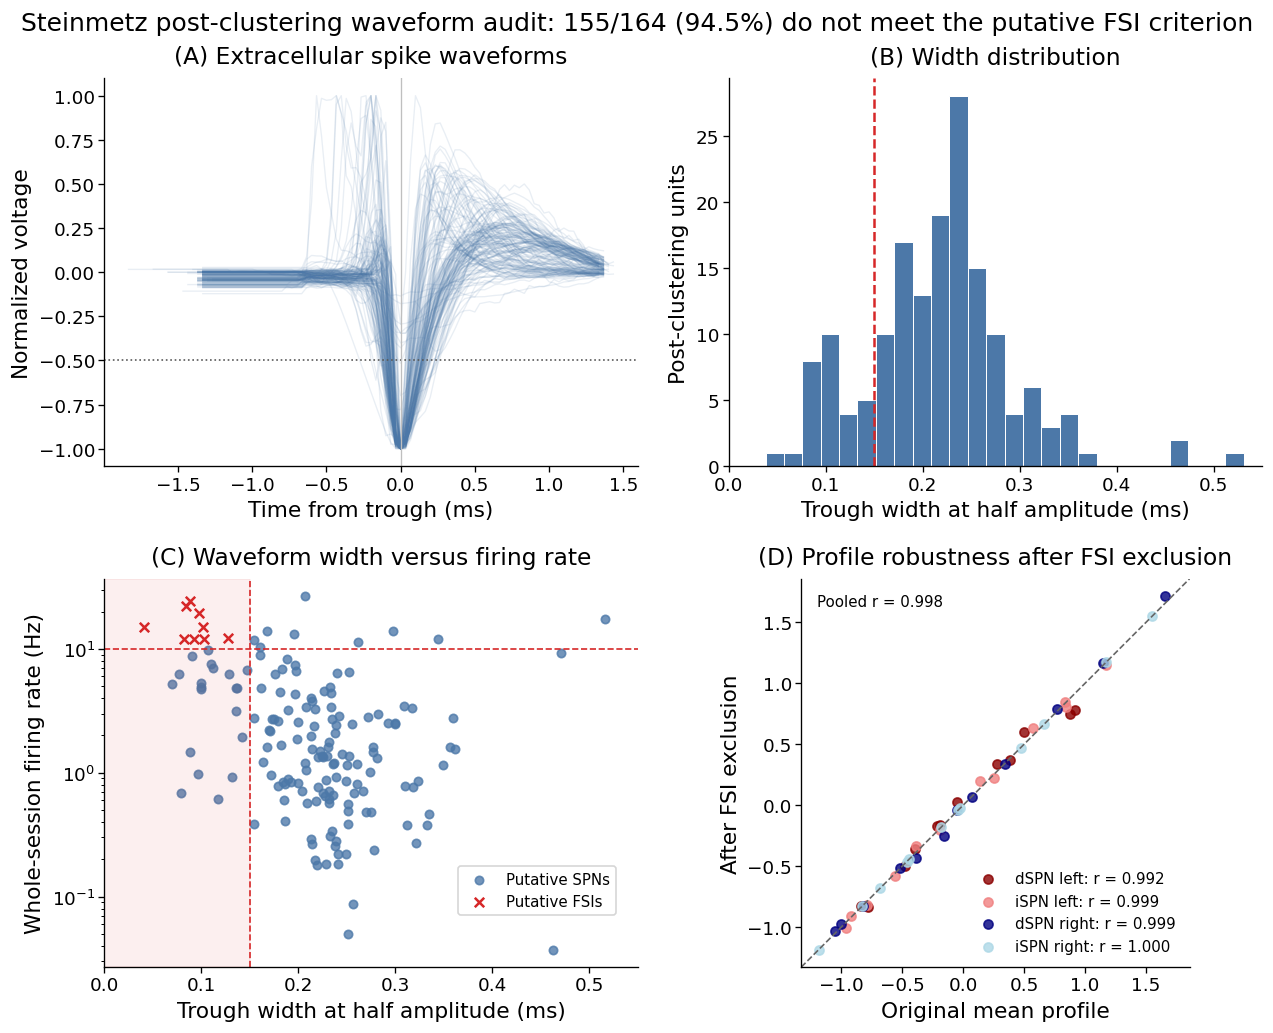

In [5]:
valid_waveforms = [item for item in waveform_rows if item["width_valid"]]
valid = audit.loc[audit["strongly_fsi_like"].notna()].copy()
if valid.empty:
    raise ValueError("No retained units have a valid waveform and firing-rate measurement.")

profiles = pd.read_csv(PROFILE_PATH)
profile_audit = profiles.merge(
    audit[["session", "unit_id", "final_name", "strongly_fsi_like"]],
    on=["session", "unit_id"],
    how="left",
    validate="many_to_one",
)
if profile_audit["final_name"].isna().any():
    raise ValueError("Some saved unit profiles could not be matched to the waveform audit.")
if not profile_audit["spn_name"].eq(profile_audit["final_name"]).all():
    raise ValueError("Saved profile labels do not match the fixed post-clustering labels.")
profile_audit["exclude_as_fsi"] = profile_audit["strongly_fsi_like"].fillna(False).astype(bool)

profile_order = ["dSPN_left", "iSPN_left", "dSPN_right", "iSPN_right"]
profile_index = pd.MultiIndex.from_product(
    [["left", "right"], range(-6, 0)],
    names=["choice_side", "bin_from_decision"],
)
profile_comparison = {}
for name in profile_order:
    subtype = profile_audit.loc[profile_audit["spn_name"].eq(name)]
    original = (
        subtype.groupby(["choice_side", "bin_from_decision"])["z_rate"]
        .mean()
        .reindex(profile_index)
    )
    filtered = (
        subtype.loc[~subtype["exclude_as_fsi"]]
        .groupby(["choice_side", "bin_from_decision"])["z_rate"]
        .mean()
        .reindex(profile_index)
    )
    if original.isna().any() or filtered.isna().any():
        raise ValueError(f"Incomplete original or FSI-filtered profile for {name}.")
    original_values = original.to_numpy(float)
    filtered_values = filtered.to_numpy(float)
    profile_comparison[name] = {
        "original": original_values,
        "filtered": filtered_values,
        "pearson_r": float(np.corrcoef(original_values, filtered_values)[0, 1]),
    }

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.5), constrained_layout=True)
fig.get_layout_engine().set(wspace=0.05, hspace=0.05)
axes = axes.ravel()

ax = axes[0]
for item in valid_waveforms:
    y = np.asarray(item["waveform"], float) - float(item["baseline"])
    scale = np.max(np.abs(y))
    if not np.isfinite(scale) or scale <= 0:
        continue
    time_ms = (np.arange(y.size) - int(item["trough_index"])) * 1000.0 / SAMPLE_RATE_HZ
    ax.plot(time_ms, y / scale, color="#4C78A8", alpha=0.12, linewidth=0.8)
ax.axhline(-0.5, color="0.35", linestyle=":", linewidth=1)
ax.axvline(0, color="0.75", linewidth=0.8)
ax.set(xlabel="Time from trough (ms)", ylabel="Normalized voltage", title="(A) Extracellular spike waveforms")

ax = axes[1]
widths = valid["trough_half_width_ms"].to_numpy(float)
upper = max(0.35, min(0.80, float(np.ceil(np.nanpercentile(widths, 99) * 20) / 20)))
bins = np.linspace(0, upper, 30)
ax.hist(widths, bins=bins, color="#4C78A8", edgecolor="white", linewidth=0.6)
ax.axvline(FSI_HALF_WIDTH_MS, color="#D62728", linestyle="--", linewidth=1.5, label="FSI screen: 0.15 ms")
ax.set(xlabel="Trough width at half amplitude (ms)", ylabel="Post-clustering units", title="(B) Width distribution", xlim=(0, upper))

ax = axes[2]
fsi = valid["strongly_fsi_like"].astype(bool).to_numpy()
rate_for_plot = np.maximum(valid["session_rate_hz"].to_numpy(float), 0.03)
ax.scatter(valid.loc[~fsi, "trough_half_width_ms"], rate_for_plot[~fsi], s=25, color="#4C78A8", alpha=0.78, label="Putative SPNs")
ax.scatter(valid.loc[fsi, "trough_half_width_ms"], rate_for_plot[fsi], s=32, color="#D62728", marker="x", linewidth=1.5, label="Putative FSIs")
ax.axvline(FSI_HALF_WIDTH_MS, color="#D62728", linestyle="--", linewidth=1)
ax.axhline(FSI_RATE_HZ, color="#D62728", linestyle="--", linewidth=1)
ax.axvspan(0, FSI_HALF_WIDTH_MS, color="#D62728", alpha=0.07)
ax.set_yscale("log")
ax.set(xlabel="Trough width at half amplitude (ms)", ylabel="Whole-session firing rate (Hz)", title="(C) Waveform width versus firing rate", xlim=(0, upper))
ax.legend(bbox_to_anchor=(0.65, 0.28))

ax = axes[3]
ax.set_aspect("equal", adjustable="box")
pooled_original = []
pooled_filtered = []
for name in profile_order:
    comparison = profile_comparison[name]
    pooled_original.append(comparison["original"])
    pooled_filtered.append(comparison["filtered"])
    ax.scatter(
        comparison["original"],
        comparison["filtered"],
        s=30,
        color=SPN_COLORS[name],
        alpha=0.80,
        label=f"{name.replace('_', ' ')}: r = {comparison['pearson_r']:.3f}",
    )
pooled_original = np.concatenate(pooled_original)
pooled_filtered = np.concatenate(pooled_filtered)
pooled_r = float(np.corrcoef(pooled_original, pooled_filtered)[0, 1])
limits = np.array([
    min(pooled_original.min(), pooled_filtered.min()),
    max(pooled_original.max(), pooled_filtered.max()),
])
padding = 0.05 * max(limits[1] - limits[0], 1.0)
limits = limits + np.array([-padding, padding])
ax.plot(limits, limits, color="0.4", linestyle="--", linewidth=1)
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set(
    xlabel="Original mean profile",
    ylabel="After FSI exclusion",
    title="(D) Profile robustness after FSI exclusion",
)
ax.text(0.04, 0.96, f"Pooled r = {pooled_r:.3f}", transform=ax.transAxes, va="top", fontsize=9)
ax.legend(frameon=False, loc="lower right", fontsize=9)

n_valid = len(valid)
n_not = int((~fsi).sum())
fraction = n_not / n_valid
fig.suptitle(
    f"Steinmetz post-clustering waveform audit: {n_not}/{n_valid} "
    f"({fraction:.1%}) do not meet the putative FSI criterion",
    fontsize=15,
)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_STEM.with_suffix(".png"), dpi=300, bbox_inches="tight")
plt.show()